## Set up and Configuration

In [2]:
# =====================================================================
# CELL 1: ENVIRONMENT SETUP & GLOBAL CONFIG
# =====================================================================
import os
import random
import numpy as np
import torch

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {DEVICE}")

# --- Dataset paths (per the Kaggle dataset structure) ---
KANO_BASE = "/kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano"
KANO_TRAIN_DIR = os.path.join(KANO_BASE, "train_folder")
KANO_TEST_DIR = os.path.join(KANO_BASE, "test_folder")

NIAID_BASE = "/kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr"
NIAID_NORMAL_DIR = os.path.join(NIAID_BASE, "Normal")
NIAID_TB_DIR = os.path.join(NIAID_BASE, "Tuberculosis")
NIAID_NORMAL_METADATA = os.path.join(NIAID_BASE, "Normal.metadata.xlsx")
NIAID_TB_METADATA = os.path.join(NIAID_BASE, "Tuberculosis.metadata.xlsx")

# --- Class configuration (4-class fine-tuning task) ---
CLASS_NAMES = ["COVID", "NORMAL", "PNEUMONIA", "TB"]  # alphabetical, matches ImageFolder convention
NUM_CLASSES = len(CLASS_NAMES)

# --- Sanity check: confirm all expected folders exist before we go further ---
paths_to_check = {
    "Kano train": KANO_TRAIN_DIR,
    "Kano test": KANO_TEST_DIR,
    "NIAID Normal": NIAID_NORMAL_DIR,
    "NIAID Tuberculosis": NIAID_TB_DIR,
}
for name, path in paths_to_check.items():
    status = " found" if os.path.exists(path) else " MISSING"
    print(f"{name:20s} -> {path}  [{status}]")

 Using device: cuda
Kano train           -> /kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/train_folder  [ found]
Kano test            -> /kaggle/input/datasets/spark2026nc/cxr-kano/cxr-kano/test_folder  [ found]
NIAID Normal         -> /kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr/Normal  [ found]
NIAID Tuberculosis   -> /kaggle/input/datasets/spark2026nc/niaid-cxr/niaid-cxr/Tuberculosis  [ found]


## Exploratory Data Analysis

 KANO DATASET (4-class, fine-tuning + evaluation)
  train / COVID      -> 500 images
  train / NORMAL     -> 500 images
  train / PNEUMONIA  -> 500 images
  train / TB         -> 500 images
  test  / COVID      -> 150 images
  test  / NORMAL     -> 150 images
  test  / PNEUMONIA  -> 150 images
  test  / TB         -> 150 images

 NIAID DATASET (binary, pretraining)
  Normal       -> 3500 images
  Tuberculosis -> 700 images


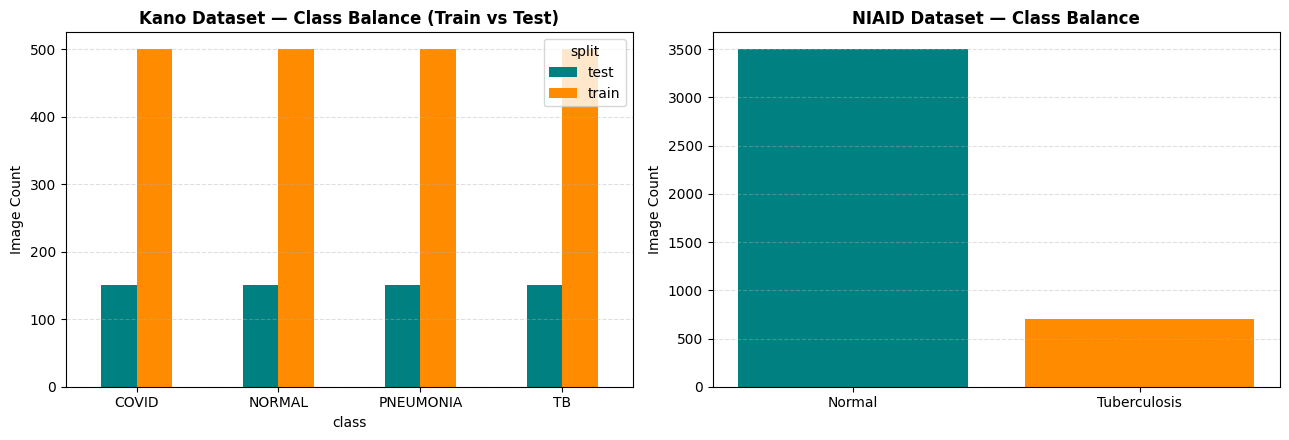


🔎 Inspecting NIAID metadata files for provenance info...

--- Normal.metadata.xlsx ---
Columns: ['FILE NAME', 'FORMAT', 'SIZE', 'URL']
Rows: 3500
  FILE NAME FORMAT     SIZE                                                    URL
0  Normal-1    PNG  512*512  https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4256233/
1  Normal-2    PNG  512*512  https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4256233/
2  Normal-3    PNG  512*512  https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4256233/

--- Tuberculosis.metadata.xlsx ---
Columns: ['FILE NAME', 'FORMAT', 'SIZE', 'URL']
Rows: 700
        FILE NAME FORMAT     SIZE                      URL
0  Tuberculosis-1    PNG  512*512  http://tuberculosis.by/
1  Tuberculosis-2    PNG  512*512  http://tuberculosis.by/
2  Tuberculosis-3    PNG  512*512  http://tuberculosis.by/


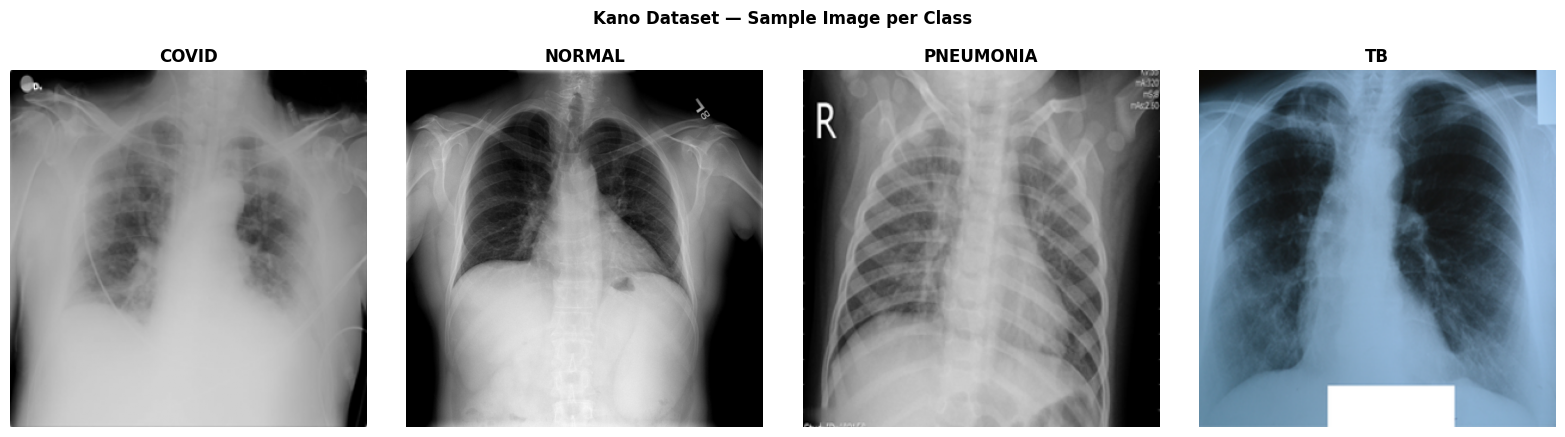

In [3]:
# =====================================================================
# CELL 2: EXPLORATORY DATA ANALYSIS
# =====================================================================
import glob
import pandas as pd
import matplotlib.pyplot as plt

def count_images(folder):
    exts = ("*.png", "*.jpg", "*.jpeg")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return len(files)

# --- 2.1: Kano dataset class balance (train + test) ---
print(" KANO DATASET (4-class, fine-tuning + evaluation)")
kano_counts = {"split": [], "class": [], "count": []}
for split_name, split_dir in [("train", KANO_TRAIN_DIR), ("test", KANO_TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        n = count_images(cls_dir)
        kano_counts["split"].append(split_name)
        kano_counts["class"].append(cls)
        kano_counts["count"].append(n)
        print(f"  {split_name:5s} / {cls:10s} -> {n} images")

kano_df = pd.DataFrame(kano_counts)

# --- 2.2: NIAID pretraining dataset class balance ---
print("\n NIAID DATASET (binary, pretraining)")
niaid_normal_n = count_images(NIAID_NORMAL_DIR)
niaid_tb_n = count_images(NIAID_TB_DIR)
print(f"  Normal       -> {niaid_normal_n} images")
print(f"  Tuberculosis -> {niaid_tb_n} images")

# --- 2.3: Bar chart of class balance across both datasets ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

kano_pivot = kano_df.pivot(index="class", columns="split", values="count")
kano_pivot.plot(kind="bar", ax=axes[0], color=["teal", "darkorange"])
axes[0].set_title("Kano Dataset — Class Balance (Train vs Test)", fontweight="bold")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, axis='y', linestyle="--", alpha=0.4)

axes[1].bar(["Normal", "Tuberculosis"], [niaid_normal_n, niaid_tb_n], color=["teal", "darkorange"])
axes[1].set_title("NIAID Dataset — Class Balance", fontweight="bold")
axes[1].set_ylabel("Image Count")
axes[1].grid(True, axis='y', linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# --- 2.4: Inspect the NIAID metadata files (may reveal image provenance / sub-source) ---
print("\n🔎 Inspecting NIAID metadata files for provenance info...")
for label, path in [("Normal", NIAID_NORMAL_METADATA), ("Tuberculosis", NIAID_TB_METADATA)]:
    if os.path.exists(path):
        try:
            meta_df = pd.read_excel(path)
            print(f"\n--- {label}.metadata.xlsx ---")
            print(f"Columns: {list(meta_df.columns)}")
            print(f"Rows: {len(meta_df)}")
            print(meta_df.head(3).to_string())
        except Exception as e:
            print(f"  Could not read {path}: {e}")
    else:
        print(f"  {path} not found.")

# --- 2.5: Peek at a few raw sample images per class (Kano) ---
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 4.2))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_dir = os.path.join(KANO_TRAIN_DIR, cls)
    sample_files = sorted(glob.glob(os.path.join(cls_dir, "*.png")) +
                           glob.glob(os.path.join(cls_dir, "*.jpg")) +
                           glob.glob(os.path.join(cls_dir, "*.jpeg")))
    if sample_files:
        img = plt.imread(sample_files[0])
        ax.imshow(img, cmap="gray")
    ax.set_title(cls, fontweight="bold")
    ax.axis("off")
plt.suptitle("Kano Dataset — Sample Image per Class", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Kano color/channel diagnostic

 Checking channel composition per class (20 samples each)...

COVID      -> 0% of sampled images have real color variance (R=133.3, G=133.3, B=133.3)
NORMAL     -> 0% of sampled images have real color variance (R=133.0, G=133.0, B=133.0)
PNEUMONIA  -> 0% of sampled images have real color variance (R=132.5, G=132.5, B=132.5)
TB         -> 5% of sampled images have real color variance (R=139.1, G=140.4, B=141.4)


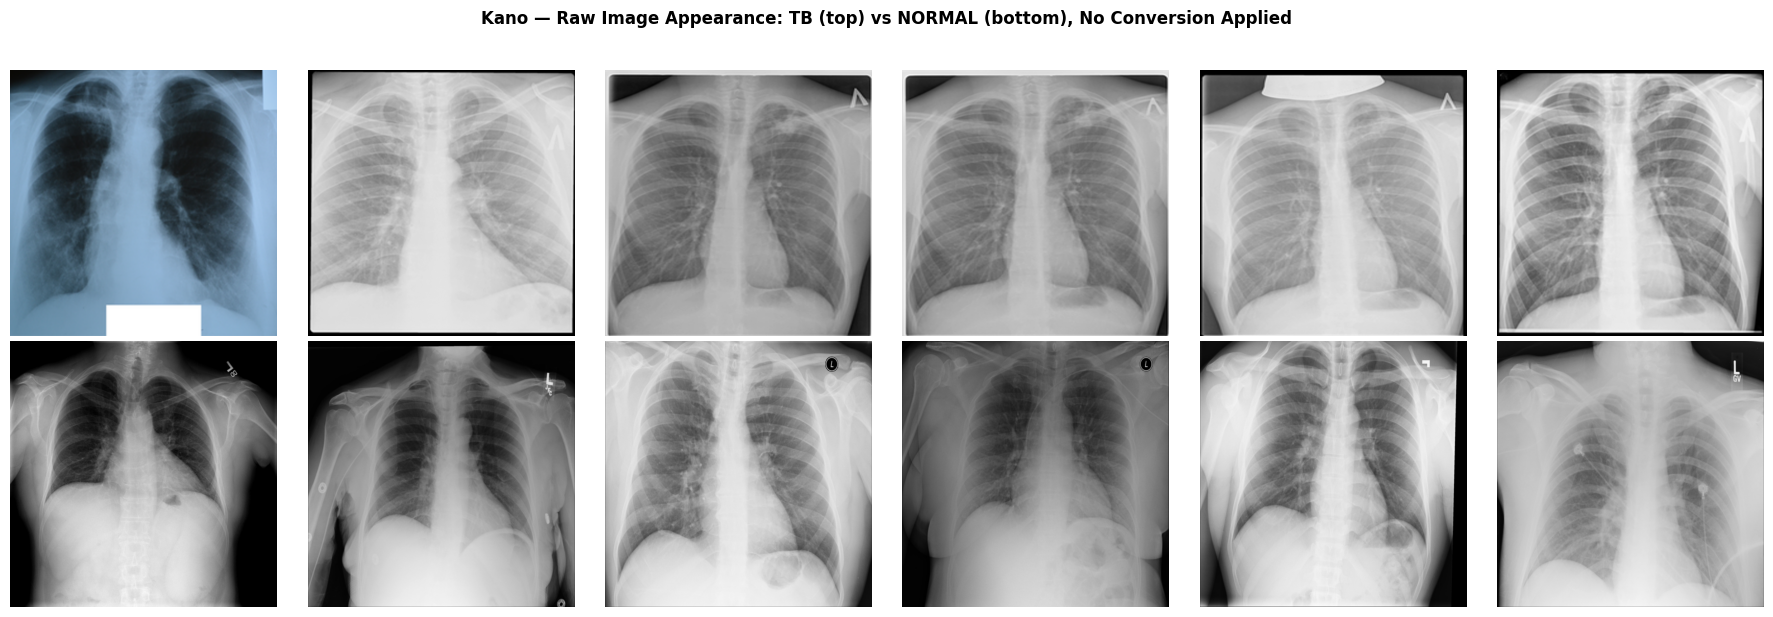

In [4]:
# =====================================================================
# CELL 3: KANO COLOR-CHANNEL / COLORIZATION DIAGNOSTIC
# =====================================================================
# Purpose: the TB sample image rendered with a visible blue tint while
# COVID/NORMAL/PNEUMONIA rendered as standard grayscale. Before designing
# the preprocessing pipeline, confirm whether this is a per-class pattern
# (a real shortcut risk for the 4-class task) or a one-off file.
# =====================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sample_channel_stats(class_dir, n_samples=20):
    exts = ("*.png", "*.jpg", "*.jpeg")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(class_dir, ext)))
    files = sorted(files)[:n_samples]

    stats = []
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_UNCHANGED)  # preserve original channels/mode
        if img is None:
            continue
        is_color = (img.ndim == 3) and not np.allclose(img[..., 0], img[..., 1])
        if img.ndim == 3:
            # cv2 loads as BGR
            b_mean, g_mean, r_mean = img[..., 0].mean(), img[..., 1].mean(), img[..., 2].mean()
        else:
            b_mean = g_mean = r_mean = img.mean()
        stats.append({
            "file": os.path.basename(f),
            "n_channels": img.ndim,
            "is_truly_color": is_color,
            "R_mean": r_mean, "G_mean": g_mean, "B_mean": b_mean
        })
    return pd.DataFrame(stats)

print(" Checking channel composition per class (20 samples each)...\n")
for cls in CLASS_NAMES:
    cls_dir = os.path.join(KANO_TRAIN_DIR, cls)
    df_stats = sample_channel_stats(cls_dir)
    pct_color = 100 * df_stats["is_truly_color"].mean() if len(df_stats) else 0
    print(f"{cls:10s} -> {pct_color:.0f}% of sampled images have real color variance "
          f"(R={df_stats['R_mean'].mean():.1f}, G={df_stats['G_mean'].mean():.1f}, B={df_stats['B_mean'].mean():.1f})")

# Visual grid: 6 TB samples vs 6 NORMAL samples, side by side, RAW (no conversion)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row, cls in enumerate(["TB", "NORMAL"]):
    cls_dir = os.path.join(KANO_TRAIN_DIR, cls)
    files = sorted(glob.glob(os.path.join(cls_dir, "*.png")) +
                   glob.glob(os.path.join(cls_dir, "*.jpg")))[:6]
    for col, f in enumerate(files):
        img = cv2.imread(f, cv2.IMREAD_UNCHANGED)
        if img.ndim == 3:
            img_disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_disp = img
        axes[row, col].imshow(img_disp, cmap="gray" if img.ndim == 2 else None)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cls, fontsize=12, fontweight="bold")

plt.suptitle("Kano — Raw Image Appearance: TB (top) vs NORMAL (bottom), No Conversion Applied",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## CLAHE preprocessing utilities

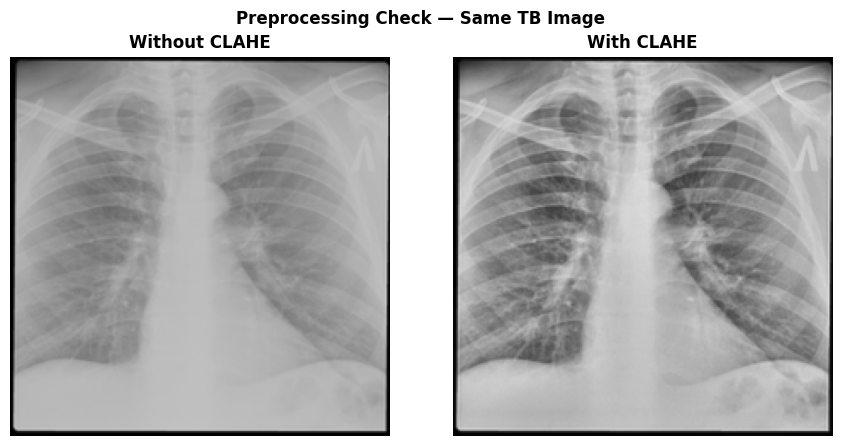

 load_and_preprocess() ready. Will be used identically for NIAID (Phase 1) and Kano (Phase 2).


In [5]:
# =====================================================================
# CELL 4: SHARED CLAHE PREPROCESSING PIPELINE
# =====================================================================
# Purpose: apply IDENTICAL preprocessing to Phase 1 (NIAID) and Phase 2
# (Kano) data. Previously, Phase 1 had no CLAHE while Phase 2 did — a
# mismatch that (a) let the NIAID Normal/TB contrast difference act as a
# shortcut, and (b) meant pretrained features didn't align with what the
# fine-tuning stage actually saw. Forcing single-channel grayscale here
# also closes off any possible color-based shortcut (Cell 3).
# =====================================================================
import cv2
import numpy as np
import torch
import torchvision.transforms as transforms
from PIL import Image

IMG_SIZE = 224
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)

def load_and_preprocess(image_path, apply_clahe=True):
    """
    Loads an image, forces single-channel grayscale (closes the color-shortcut
    risk from Cell 3), optionally applies CLAHE contrast normalization
    (closes the brightness/contrast shortcut risk from Step 3.6), resizes,
    and converts to 3-channel RGB (required for ImageNet-pretrained backbones).
    Returns a PIL Image ready for torchvision transforms.
    """
    img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # forces grayscale regardless of source

    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
        img_gray = clahe.apply(img_gray)

    img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb)

# --- Normalization stats (ImageNet defaults, since both backbones start from ImageNet weights) ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

eval_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Quick visual check: same image, with vs without CLAHE, to confirm the pipeline works ---
sample_tb = sorted(glob.glob(os.path.join(KANO_TRAIN_DIR, "TB", "*.png")))[1]  # skip the colorized outlier at index 0

img_no_clahe = load_and_preprocess(sample_tb, apply_clahe=False)
img_with_clahe = load_and_preprocess(sample_tb, apply_clahe=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_no_clahe, cmap="gray")
axes[0].set_title("Without CLAHE", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(img_with_clahe, cmap="gray")
axes[1].set_title("With CLAHE", fontweight="bold")
axes[1].axis("off")
plt.suptitle("Preprocessing Check — Same TB Image", fontweight="bold")
plt.tight_layout()
plt.show()

print(" load_and_preprocess() ready. Will be used identically for NIAID (Phase 1) and Kano (Phase 2).")

## Dataset classes for both NIAID (binary) and Kano (4-class)

In [6]:
# =====================================================================
# CELL 5: DATASET CLASSES (NIAID BINARY + KANO 4-CLASS)
# =====================================================================
from torch.utils.data import Dataset

class NiaidPretrainDataset(Dataset):
    """Binary TB-vs-Normal dataset for Phase 1 pretraining."""
    def __init__(self, base_dir, transform=None, apply_clahe=True):
        self.transform = transform
        self.apply_clahe = apply_clahe
        self.image_data = []
        self.class_names = ["NORMAL", "TB"]  # index 0 = Normal, index 1 = TB

        for label_idx, folder_name in enumerate(["Normal", "Tuberculosis"]):
            class_folder = os.path.join(base_dir, folder_name)
            exts = ("*.png", "*.jpg", "*.jpeg")
            files = []
            for ext in exts:
                files.extend(glob.glob(os.path.join(class_folder, ext)))
            for img_path in sorted(files):
                self.image_data.append((img_path, label_idx))

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        image = load_and_preprocess(img_path, apply_clahe=self.apply_clahe)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


class KanoCXRDataset(Dataset):
    """4-class (COVID / NORMAL / PNEUMONIA / TB) dataset for Phase 2 fine-tuning + evaluation."""
    def __init__(self, base_dir, transform=None, apply_clahe=True):
        self.transform = transform
        self.apply_clahe = apply_clahe
        self.image_data = []
        self.class_names = CLASS_NAMES  # ["COVID", "NORMAL", "PNEUMONIA", "TB"], alphabetical

        for label_idx, cls in enumerate(self.class_names):
            class_folder = os.path.join(base_dir, cls)
            exts = ("*.png", "*.jpg", "*.jpeg")
            files = []
            for ext in exts:
                files.extend(glob.glob(os.path.join(class_folder, ext)))
            for img_path in sorted(files):
                self.image_data.append((img_path, label_idx))

    def __len__(self):
        return len(self.image_data)

    def __getitem__(self, idx):
        img_path, label = self.image_data[idx]
        image = load_and_preprocess(img_path, apply_clahe=self.apply_clahe)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


# --- Quick sanity instantiation (no training yet, just confirm counts match EDA) ---
niaid_check = NiaidPretrainDataset(NIAID_BASE, transform=None)
kano_train_check = KanoCXRDataset(KANO_TRAIN_DIR, transform=None)
kano_test_check = KanoCXRDataset(KANO_TEST_DIR, transform=None)

print(f" NIAID dataset: {len(niaid_check)} images "
      f"(expect 4200 = 3500 Normal + 700 TB)")
print(f" Kano train dataset: {len(kano_train_check)} images (expect 2000 = 500 x 4)")
print(f" Kano test dataset: {len(kano_test_check)} images (expect 600 = 150 x 4)")

 NIAID dataset: 4200 images (expect 4200 = 3500 Normal + 700 TB)
 Kano train dataset: 2000 images (expect 2000 = 500 x 4)
 Kano test dataset: 600 images (expect 600 = 150 x 4)


## Phase 1 pretraining

 Initializing Phase 1 Dataset...
 Verified pretraining pool size: 4200 images.
Building ImageNet-initialized DenseNet121 for TB-vs-Normal pretraining...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 160MB/s] 


🚀 Training Phase 1 backbone for up to 100 epochs (patience=8) on cuda...
Epoch [01/100] -> Train Loss: 0.0709 Acc: 0.9742 | Val Loss: 0.0104 Acc: 0.9968
Epoch [02/100] -> Train Loss: 0.0095 Acc: 0.9972 | Val Loss: 0.0038 Acc: 1.0000
Epoch [03/100] -> Train Loss: 0.0118 Acc: 0.9964 | Val Loss: 0.0040 Acc: 1.0000
Epoch [04/100] -> Train Loss: 0.0053 Acc: 0.9986 | Val Loss: 0.0088 Acc: 0.9984
Epoch [05/100] -> Train Loss: 0.0011 Acc: 1.0000 | Val Loss: 0.0047 Acc: 0.9984
Epoch [06/100] -> Train Loss: 0.0013 Acc: 0.9997 | Val Loss: 0.0024 Acc: 0.9984
Epoch [07/100] -> Train Loss: 0.0015 Acc: 0.9994 | Val Loss: 0.0124 Acc: 0.9968
Epoch [08/100] -> Train Loss: 0.0024 Acc: 0.9997 | Val Loss: 0.0031 Acc: 0.9968
Epoch [09/100] -> Train Loss: 0.0035 Acc: 0.9992 | Val Loss: 0.0166 Acc: 0.9968
Epoch [10/100] -> Train Loss: 0.0059 Acc: 0.9980 | Val Loss: 0.0024 Acc: 0.9984
Epoch [11/100] -> Train Loss: 0.0004 Acc: 1.0000 | Val Loss: 0.0042 Acc: 0.9984
Epoch [12/100] -> Train Loss: 0.0009 Acc: 0.999

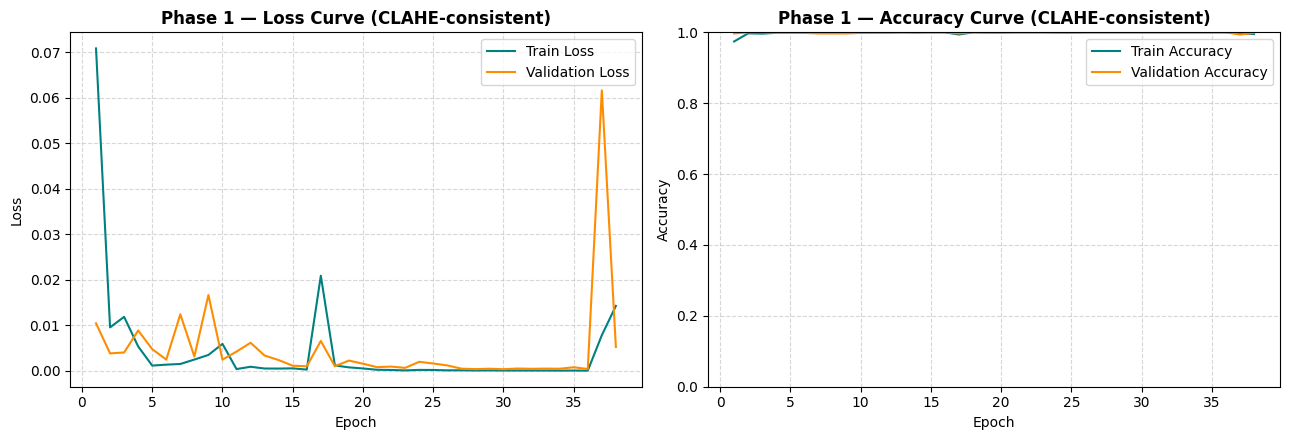

 Saved converged backbone to all 5 fold checkpoint files.


In [8]:
# =====================================================================
# CELL 6: PHASE 1 — TB-VS-NORMAL PRETRAINING (NIAID, CLAHE-CONSISTENT)
# =====================================================================
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import train_test_split
from torchvision.models import densenet121, DenseNet121_Weights

def execute_phase1_pretraining(epochs=100, lr=1e-4, patience=8, batch_size=32):
    print(" Initializing Phase 1 Dataset...")
    full_dataset = NiaidPretrainDataset(NIAID_BASE, transform=None, apply_clahe=True)
    labels = [lbl for _, lbl in full_dataset.image_data]
    total = len(full_dataset)
    print(f" Verified pretraining pool size: {total} images.")

    # Stratified train/val split
    all_indices = list(range(total))
    train_idx, val_idx = train_test_split(
        all_indices, test_size=0.15, stratify=labels, random_state=SEED
    )

    # Two views of the same underlying dataset with different transforms
    train_view = NiaidPretrainDataset(NIAID_BASE, transform=train_transforms, apply_clahe=True)
    val_view = NiaidPretrainDataset(NIAID_BASE, transform=eval_transforms, apply_clahe=True)

    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    # Class-balance sampler on the train split only
    train_labels = [labels[i] for i in train_idx]
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    sample_weights = np.array([class_weights[y] for y in train_labels])
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_subset, batch_size=batch_size, sampler=sampler, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)

    print("Building ImageNet-initialized DenseNet121 for TB-vs-Normal pretraining...")
    model = densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features, 2)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"🚀 Training Phase 1 backbone for up to {epochs} epochs (patience={patience}) on {DEVICE}...")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total_n = 0.0, 0, 0
        for images, lbls in train_loader:
            images, lbls = images.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            total_n += lbls.size(0)
        train_loss = running_loss / total_n
        train_acc = correct / total_n

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, lbls in val_loader:
                images, lbls = images.to(DEVICE), lbls.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, lbls)
                val_loss_sum += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == lbls).sum().item()
                val_total += lbls.size(0)
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1:02d}/{epochs}] -> Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f" Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    print(f"\n Phase 1 pretraining converged. Best val loss: {best_val_loss:.4f}")

    epochs_run = len(history["train_loss"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(range(1, epochs_run + 1), history["train_loss"], label="Train Loss", color="teal")
    axes[0].plot(range(1, epochs_run + 1), history["val_loss"], label="Validation Loss", color="darkorange")
    axes[0].set_title("Phase 1 — Loss Curve (CLAHE-consistent)", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(range(1, epochs_run + 1), history["train_acc"], label="Train Accuracy", color="teal")
    axes[1].plot(range(1, epochs_run + 1), history["val_acc"], label="Validation Accuracy", color="darkorange")
    axes[1].set_title("Phase 1 — Accuracy Curve (CLAHE-consistent)", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.0)
    axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    for fold in range(1, 6):
        torch.save(best_state, f"custom_pretrained_backbone_fold{fold}.pth")
    print(" Saved converged backbone to all 5 fold checkpoint files.")

    return best_val_loss, history

best_val_loss, phase1_history = execute_phase1_pretraining(epochs=100, lr=1e-4, patience=8)

⏳ Computing sharpness and border statistics...

 Summary by class:
       sharpness_laplacian_var        border_mean        border_std       
                          mean    std        mean    std       mean    std
label                                                                     
NORMAL                  121.19  98.40      104.71  31.21      80.60  13.62
TB                       29.40  35.65      109.36  52.25      60.68  17.55


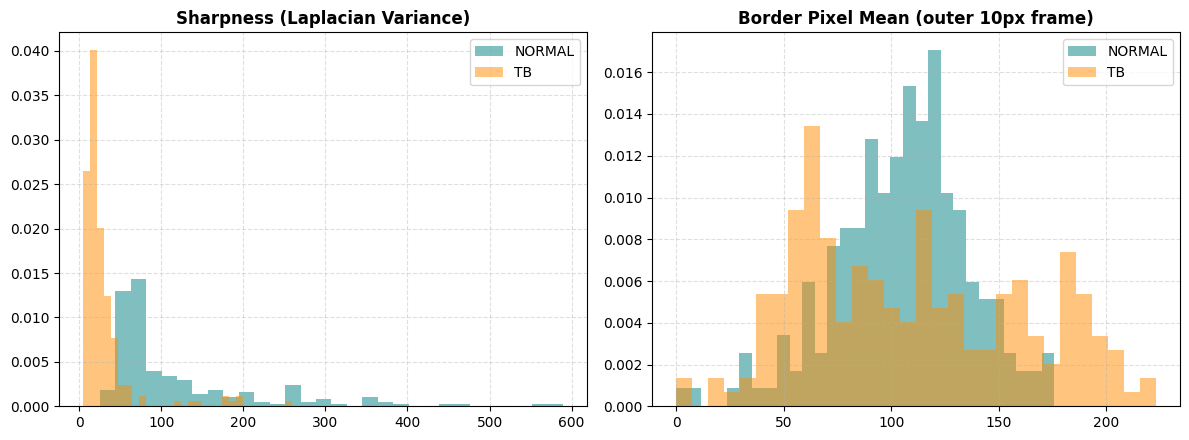

sharpness_laplacian_var: t=12.40, p=7.37e-28  LIKELY DIFFERENT
border_mean: t=-1.08, p=2.80e-01 


In [9]:
# =====================================================================
# CELL 6.5: SHARPNESS & BORDER DIAGNOSTIC (NIAID NORMAL vs TB)
# =====================================================================
# Purpose: CLAHE normalizes contrast but NOT sharpness/blur or border framing.
# If Normal and TB differ systematically here, that's a shortcut no amount
# of contrast preprocessing will remove — it reflects the two classes coming
# from genuinely different acquisition/digitization pipelines.
# =====================================================================
def sharpness_and_border_stats(class_folder, label, n_samples=200):
    exts = ("*.png", "*.jpg", "*.jpeg")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(class_folder, ext)))
    files = sorted(files)[:n_samples]

    rows = []
    for f in files:
        img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()  # sharpness proxy
        border_thickness = 10
        border_pixels = np.concatenate([
            img[:border_thickness, :].flatten(),
            img[-border_thickness:, :].flatten(),
            img[:, :border_thickness].flatten(),
            img[:, -border_thickness:].flatten()
        ])
        rows.append({
            "label": label,
            "sharpness_laplacian_var": laplacian_var,
            "border_mean": border_pixels.mean(),
            "border_std": border_pixels.std()
        })
    return pd.DataFrame(rows)

print("⏳ Computing sharpness and border statistics...")
normal_stats = sharpness_and_border_stats(NIAID_NORMAL_DIR, "NORMAL")
tb_stats = sharpness_and_border_stats(NIAID_TB_DIR, "TB")
combined = pd.concat([normal_stats, tb_stats], ignore_index=True)

print("\n Summary by class:")
print(combined.groupby("label")[["sharpness_laplacian_var", "border_mean", "border_std"]].agg(["mean", "std"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, color in [("NORMAL", "teal"), ("TB", "darkorange")]:
    axes[0].hist(combined[combined.label == label]["sharpness_laplacian_var"], bins=30, alpha=0.5, label=label, color=color, density=True)
    axes[1].hist(combined[combined.label == label]["border_mean"], bins=30, alpha=0.5, label=label, color=color, density=True)
axes[0].set_title("Sharpness (Laplacian Variance)", fontweight="bold")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.4)
axes[1].set_title("Border Pixel Mean (outer 10px frame)", fontweight="bold")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

from scipy import stats as sstats
for stat in ["sharpness_laplacian_var", "border_mean"]:
    t, p = sstats.ttest_ind(combined[combined.label=="NORMAL"][stat], combined[combined.label=="TB"][stat], equal_var=False)
    print(f"{stat}: t={t:.2f}, p={p:.2e} {' LIKELY DIFFERENT' if p < 0.001 else ''}")

⏳ Initializing Phase 1 Dataset...
📁 Verified pretraining pool size: 4200 images.
Building ImageNet-initialized DenseNet121 for TB-vs-Normal pretraining...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 202MB/s]


🚀 Training Phase 1 backbone (blur-augmented) for up to 10 epochs (patience=3) on cuda...
Epoch [01/10] -> Train Loss: 0.1155 Acc: 0.9583 | Val Loss: 0.0276 Acc: 0.9952
Epoch [02/10] -> Train Loss: 0.0239 Acc: 0.9927 | Val Loss: 0.0194 Acc: 0.9952
Epoch [03/10] -> Train Loss: 0.0267 Acc: 0.9905 | Val Loss: 0.0068 Acc: 0.9984
Epoch [04/10] -> Train Loss: 0.0169 Acc: 0.9952 | Val Loss: 0.0072 Acc: 0.9984
Epoch [05/10] -> Train Loss: 0.0074 Acc: 0.9983 | Val Loss: 0.0177 Acc: 0.9952
Epoch [06/10] -> Train Loss: 0.0046 Acc: 0.9992 | Val Loss: 0.0059 Acc: 0.9968
Epoch [07/10] -> Train Loss: 0.0032 Acc: 0.9986 | Val Loss: 0.0026 Acc: 0.9984
Epoch [08/10] -> Train Loss: 0.0081 Acc: 0.9972 | Val Loss: 0.0036 Acc: 0.9984
Epoch [09/10] -> Train Loss: 0.0044 Acc: 0.9989 | Val Loss: 0.0026 Acc: 1.0000
Epoch [10/10] -> Train Loss: 0.0040 Acc: 0.9989 | Val Loss: 0.0104 Acc: 0.9952

✅ Phase 1 pretraining complete. Best val loss: 0.0026
⚠️  REMINDER: this val accuracy reflects a known cross-source blur

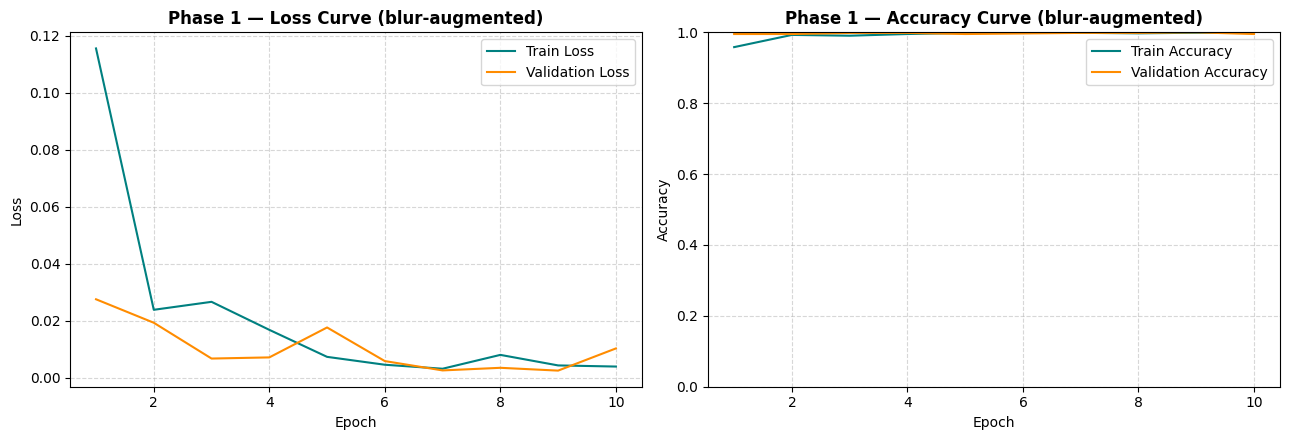

 Saved converged backbone to all 5 fold checkpoint files.


In [7]:
# =====================================================================
# CELL 6: PHASE 1 — TB-VS-NORMAL PRETRAINING (NIAID)
# =====================================================================
# KNOWN LIMITATION (documented for the paper):
# NIAID's Normal and Tuberculosis images come from two unrelated external
# sources (NCBI archival collection vs. a Belarusian TB imaging database).
# Diagnostic testing found NORMAL images are systematically sharper than
# TB images (Laplacian variance 121.2±98.4 vs 29.4±35.6, p=7.4e-28), while
# CLAHE-normalized contrast and border framing showed no such gap. This
# means a model can achieve high accuracy on this pretraining task partly
# by exploiting cross-source blur differences rather than TB pathology.
# MITIGATION: random Gaussian blur is applied to BOTH classes during
# training so blur alone cannot serve as a reliable class signal. This
# reduces, but does not eliminate, the confound — Phase 1's own val
# accuracy should NOT be treated as evidence of real TB-detection ability.
# The only trustworthy signal is downstream Kano (Phase 2) performance,
# since Kano is single-hospital / single-pipeline across all 4 classes.
# =====================================================================
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from sklearn.model_selection import train_test_split
from torchvision.models import densenet121, DenseNet121_Weights
import torchvision.transforms as transforms

# Phase-1-specific training transform: adds random blur mitigation on top
# of the standard augmentations, applied to BOTH classes equally.
phase1_train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.5, 2.5))], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def execute_phase1_pretraining(epochs=10, lr=1e-4, patience=3, batch_size=32):
    print("⏳ Initializing Phase 1 Dataset...")
    full_dataset = NiaidPretrainDataset(NIAID_BASE, transform=None, apply_clahe=True)
    labels = [lbl for _, lbl in full_dataset.image_data]
    total = len(full_dataset)
    print(f"📁 Verified pretraining pool size: {total} images.")

    all_indices = list(range(total))
    train_idx, val_idx = train_test_split(
        all_indices, test_size=0.15, stratify=labels, random_state=SEED
    )

    train_view = NiaidPretrainDataset(NIAID_BASE, transform=phase1_train_transforms, apply_clahe=True)
    val_view = NiaidPretrainDataset(NIAID_BASE, transform=eval_transforms, apply_clahe=True)

    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    train_labels = [labels[i] for i in train_idx]
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    sample_weights = np.array([class_weights[y] for y in train_labels])
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_subset, batch_size=batch_size, sampler=sampler, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)

    print("Building ImageNet-initialized DenseNet121 for TB-vs-Normal pretraining...")
    model = densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features, 2)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"🚀 Training Phase 1 backbone (blur-augmented) for up to {epochs} epochs "
          f"(patience={patience}) on {DEVICE}...")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total_n = 0.0, 0, 0
        for images, lbls in train_loader:
            images, lbls = images.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            total_n += lbls.size(0)
        train_loss = running_loss / total_n
        train_acc = correct / total_n

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, lbls in val_loader:
                images, lbls = images.to(DEVICE), lbls.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, lbls)
                val_loss_sum += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == lbls).sum().item()
                val_total += lbls.size(0)
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        print(f"Epoch [{epoch+1:02d}/{epochs}] -> Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"⏹ Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
                break

    print(f"\n✅ Phase 1 pretraining complete. Best val loss: {best_val_loss:.4f}")
    print("⚠️  REMINDER: this val accuracy reflects a known cross-source blur confound")
    print("    in the NIAID dataset (see cell header). Treat it as a coarse initializer,")
    print("    not as evidence of genuine TB-detection ability.")

    epochs_run = len(history["train_loss"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(range(1, epochs_run + 1), history["train_loss"], label="Train Loss", color="teal")
    axes[0].plot(range(1, epochs_run + 1), history["val_loss"], label="Validation Loss", color="darkorange")
    axes[0].set_title("Phase 1 — Loss Curve (blur-augmented)", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].plot(range(1, epochs_run + 1), history["train_acc"], label="Train Accuracy", color="teal")
    axes[1].plot(range(1, epochs_run + 1), history["val_acc"], label="Validation Accuracy", color="darkorange")
    axes[1].set_title("Phase 1 — Accuracy Curve (blur-augmented)", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0, 1.0)
    axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    for fold in range(1, 6):
        torch.save(best_state, f"custom_pretrained_backbone_fold{fold}.pth")
    print(" Saved converged backbone to all 5 fold checkpoint files.")

    return best_val_loss, history

best_val_loss, phase1_history = execute_phase1_pretraining(epochs=10, lr=1e-4, patience=3)

## Kano dataset + Stratified 5-fold split setup

In [8]:
# =====================================================================
# CELL 7: KANO DATASET + STRATIFIED 5-FOLD CV SETUP
# =====================================================================
# FIX: original notebook used plain KFold, which doesn't guarantee each
# fold's train/val split preserves the 4-class balance. StratifiedKFold
# removes that source of fold-to-fold noise.
# =====================================================================
from sklearn.model_selection import StratifiedKFold

# Full Kano training pool (2000 images: 500 per class)
kano_full_dataset = KanoCXRDataset(KANO_TRAIN_DIR, transform=None, apply_clahe=True)
kano_labels = [lbl for _, lbl in kano_full_dataset.image_data]

print(f" Kano training pool: {len(kano_full_dataset)} images")
print(f"   Class distribution: {dict(zip(*np.unique(kano_labels, return_counts=True)))}")
print(f"   (Label indices map to: {list(enumerate(CLASS_NAMES))})")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Precompute the fold splits once so both Model A and Model B tournaments
# use IDENTICAL splits — this keeps the comparison fair (same data seen
# by both models in each fold, only the model/optimizer strategy differs).
fold_splits = list(skf.split(np.zeros(len(kano_labels)), kano_labels))

print(f"\n Prepared {N_FOLDS} stratified folds (shared by Model A and Model B).")
for i, (train_idx, val_idx) in enumerate(fold_splits, 1):
    fold_train_labels = [kano_labels[j] for j in train_idx]
    fold_val_labels = [kano_labels[j] for j in val_idx]
    train_dist = dict(zip(*np.unique(fold_train_labels, return_counts=True)))
    val_dist = dict(zip(*np.unique(fold_val_labels, return_counts=True)))
    print(f"  Fold {i}: train={len(train_idx)} {train_dist} | val={len(val_idx)} {val_dist}")

# Held-out test set (separate from CV entirely — never touched until final eval)
kano_test_dataset_check = KanoCXRDataset(KANO_TEST_DIR, transform=eval_transforms, apply_clahe=True)
print(f"\n Held-out test set: {len(kano_test_dataset_check)} images (untouched by CV)")

 Kano training pool: 2000 images
   Class distribution: {np.int64(0): np.int64(500), np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500)}
   (Label indices map to: [(0, 'COVID'), (1, 'NORMAL'), (2, 'PNEUMONIA'), (3, 'TB')])

 Prepared 5 stratified folds (shared by Model A and Model B).
  Fold 1: train=1600 {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)} | val=400 {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}
  Fold 2: train=1600 {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)} | val=400 {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100)}
  Fold 3: train=1600 {np.int64(0): np.int64(400), np.int64(1): np.int64(400), np.int64(2): np.int64(400), np.int64(3): np.int64(400)} | val=400 {np.int64(0): np.int64(1

##  Shared fine-tuning function (used by both Model A and Model B)

In [9]:
# =====================================================================
# CELL 8: SHARED FINE-TUNING ENGINE (used by both Model A and Model B)
# =====================================================================
# Both models call this SAME function. The only differences between them
# are passed in as arguments: whether to load the Phase 1 checkpoint, and
# whether to use LLRD (layer-wise decayed learning rates) or a uniform LR.
# Keeping everything else identical (data, splits, loss, epochs, patience,
# augmentation) is what makes the eventual Model A vs Model B comparison
# actually isolate the variable we care about.
# =====================================================================
from torch.optim.lr_scheduler import CosineAnnealingLR

# Class weights: cost-sensitive weighting reflecting clinical priority
# (missing a TB case is costlier than misclassifying COVID/Pneumonia).
# Order matches CLASS_NAMES = ["COVID", "NORMAL", "PNEUMONIA", "TB"]
CLASS_LOSS_WEIGHTS = torch.tensor([1.5, 1.0, 1.0, 2.2]).to(DEVICE)

def build_model(pretrained_checkpoint_path=None):
    """Builds a DenseNet121 with a 4-class head, optionally initialized
    from a Phase 1 binary checkpoint."""
    if pretrained_checkpoint_path is not None:
        model = densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, 2)
        model.load_state_dict(torch.load(pretrained_checkpoint_path, map_location=DEVICE))
    else:
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)

    model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    return model.to(DEVICE)

def build_optimizer(model, use_llrd=False, base_lr=1e-4):
    """Either uniform LR across all params, or LLRD with 3 param groups:
    early backbone layers (denseblock1-2), deep backbone layers
    (denseblock3-4 + norm5), and the classifier head."""
    if not use_llrd:
        return optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-2)

    early_params, deep_params, head_params = [], [], []
    for name, param in model.named_parameters():
        if "classifier" in name:
            head_params.append(param)
        elif "denseblock1" in name or "denseblock2" in name:
            early_params.append(param)
        else:
            deep_params.append(param)

    return optim.AdamW([
        {"params": early_params, "lr": 2e-6},
        {"params": deep_params, "lr": 1e-5},
        {"params": head_params, "lr": 5e-4},
    ], weight_decay=1e-2)

def train_one_fold(fold_idx, train_idx, val_idx, model_tag, pretrained_checkpoint_path=None,
                    use_llrd=False, epochs=20, patience=5, batch_size=32):
    train_view = KanoCXRDataset(KANO_TRAIN_DIR, transform=train_transforms, apply_clahe=True)
    val_view = KanoCXRDataset(KANO_TRAIN_DIR, transform=eval_transforms, apply_clahe=True)

    train_subset = Subset(train_view, train_idx)
    val_subset = Subset(val_view, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)

    model = build_model(pretrained_checkpoint_path)
    optimizer = build_optimizer(model, use_llrd=use_llrd)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=CLASS_LOSS_WEIGHTS)

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    print(f"  [Model {model_tag} | Fold {fold_idx}] Training "
          f"({'LLRD' if use_llrd else 'uniform LR'}, "
          f"{'pretrained' if pretrained_checkpoint_path else 'ImageNet-only'})...")

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total_n = 0.0, 0, 0
        for images, lbls in train_loader:
            images, lbls = images.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == lbls).sum().item()
            total_n += lbls.size(0)
        train_loss = running_loss / total_n
        train_acc = correct / total_n
        scheduler.step()

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, lbls in val_loader:
                images, lbls = images.to(DEVICE), lbls.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, lbls)
                val_loss_sum += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == lbls).sum().item()
                val_total += lbls.size(0)
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    print(f"    -> Fold {fold_idx} done. Best val loss: {best_val_loss:.4f}, "
          f"Best val acc: {max(history['val_acc']):.4f} ({len(history['train_loss'])} epochs run)")

    checkpoint_name = f"model{model_tag}_fold{fold_idx}.pth"
    torch.save(best_state, checkpoint_name)

    return best_val_loss, history, checkpoint_name

print(" Shared fine-tuning engine ready: build_model(), build_optimizer(), train_one_fold()")

 Shared fine-tuning engine ready: build_model(), build_optimizer(), train_one_fold()


## Model A tournament (5 folds, TB-pretrained + LLRD)

MODEL A TOURNAMENT — 5-Fold CV | TB/Normal Pretrained + LLRD
  [Model A | Fold 1] Training (LLRD, pretrained)...
    -> Fold 1 done. Best val loss: 0.0441, Best val acc: 0.9875 (13 epochs run)
  [Model A | Fold 2] Training (LLRD, pretrained)...
    -> Fold 2 done. Best val loss: 0.0154, Best val acc: 0.9975 (20 epochs run)
  [Model A | Fold 3] Training (LLRD, pretrained)...
    -> Fold 3 done. Best val loss: 0.0105, Best val acc: 1.0000 (20 epochs run)
  [Model A | Fold 4] Training (LLRD, pretrained)...
    -> Fold 4 done. Best val loss: 0.0141, Best val acc: 0.9975 (20 epochs run)
  [Model A | Fold 5] Training (LLRD, pretrained)...
    -> Fold 5 done. Best val loss: 0.0267, Best val acc: 0.9925 (20 epochs run)

MODEL A TOURNAMENT SUMMARY
  Fold 1: best val loss=0.0441, best val acc=0.9875
  Fold 2: best val loss=0.0154, best val acc=0.9975
  Fold 3: best val loss=0.0105, best val acc=1.0000
  Fold 4: best val loss=0.0141, best val acc=0.9975
  Fold 5: best val loss=0.0267, best val ac

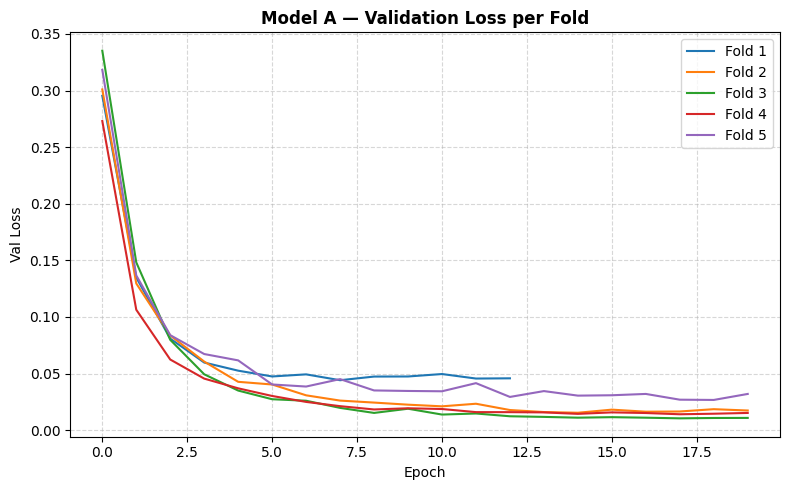

In [11]:
# =====================================================================
# CELL 9: MODEL A TOURNAMENT — TB-PRETRAINED BACKBONE + LLRD
# =====================================================================
model_a_results = {}

print("=" * 70)
print("MODEL A TOURNAMENT — 5-Fold CV | TB/Normal Pretrained + LLRD")
print("=" * 70)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    checkpoint_path = f"custom_pretrained_backbone_fold{fold_idx}.pth"  # identical converged backbone, per fold slot
    best_val_loss, history, ckpt_name = train_one_fold(
        fold_idx=fold_idx,
        train_idx=train_idx,
        val_idx=val_idx,
        model_tag="A",
        pretrained_checkpoint_path=checkpoint_path,
        use_llrd=True,
        epochs=20,
        patience=5
    )
    model_a_results[fold_idx] = {
        "best_val_loss": best_val_loss,
        "best_val_acc": max(history["val_acc"]),
        "history": history,
        "checkpoint": ckpt_name
    }

print("\n" + "=" * 70)
print("MODEL A TOURNAMENT SUMMARY")
print("=" * 70)
for fold_idx, res in model_a_results.items():
    print(f"  Fold {fold_idx}: best val loss={res['best_val_loss']:.4f}, best val acc={res['best_val_acc']:.4f}")

avg_val_acc_a = np.mean([r["best_val_acc"] for r in model_a_results.values()])
std_val_acc_a = np.std([r["best_val_acc"] for r in model_a_results.values()])
print(f"\n  Mean best val acc across folds: {avg_val_acc_a:.4f} ± {std_val_acc_a:.4f}")

# Plot all 5 folds' val loss curves together, to see fold-to-fold stability
fig, ax = plt.subplots(figsize=(8, 5))
for fold_idx, res in model_a_results.items():
    ax.plot(res["history"]["val_loss"], label=f"Fold {fold_idx}")
ax.set_title("Model A — Validation Loss per Fold", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Model B tournament (5 folds, ImageNet-only + uniform LR)

MODEL B TOURNAMENT — 5-Fold CV | ImageNet-Only + Uniform LR
  [Model B | Fold 1] Training (uniform LR, ImageNet-only)...
    -> Fold 1 done. Best val loss: 0.0409, Best val acc: 0.9900 (10 epochs run)
  [Model B | Fold 2] Training (uniform LR, ImageNet-only)...
    -> Fold 2 done. Best val loss: 0.0240, Best val acc: 0.9925 (15 epochs run)
  [Model B | Fold 3] Training (uniform LR, ImageNet-only)...
    -> Fold 3 done. Best val loss: 0.0021, Best val acc: 1.0000 (16 epochs run)
  [Model B | Fold 4] Training (uniform LR, ImageNet-only)...
    -> Fold 4 done. Best val loss: 0.0121, Best val acc: 0.9975 (9 epochs run)
  [Model B | Fold 5] Training (uniform LR, ImageNet-only)...
    -> Fold 5 done. Best val loss: 0.0148, Best val acc: 0.9950 (13 epochs run)

MODEL B TOURNAMENT SUMMARY
  Fold 1: best val loss=0.0409, best val acc=0.9900
  Fold 2: best val loss=0.0240, best val acc=0.9925
  Fold 3: best val loss=0.0021, best val acc=1.0000
  Fold 4: best val loss=0.0121, best val acc=0.9975


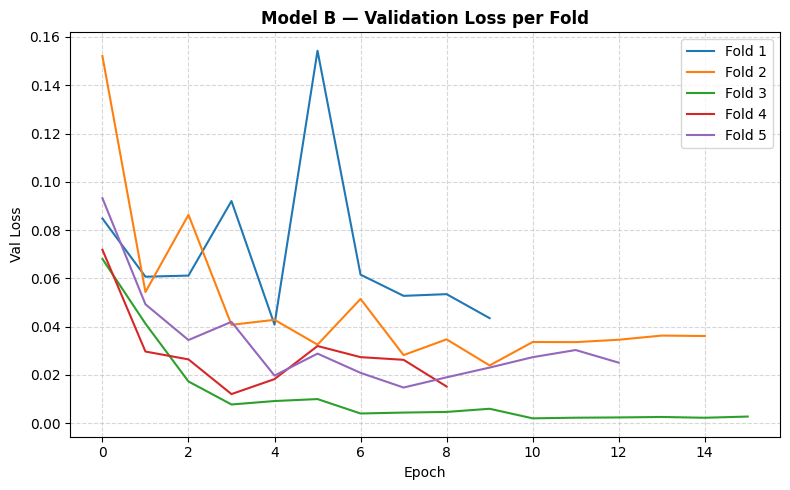


MODEL A vs MODEL B — CROSS-VALIDATION SUMMARY
  Model A (pretrained + LLRD): 0.9950 ± 0.0045
  Model B (ImageNet + uniform LR): 0.9950 ± 0.0035


In [12]:
# =====================================================================
# CELL 10: MODEL B TOURNAMENT — IMAGENET-ONLY BACKBONE + UNIFORM LR
# =====================================================================
model_b_results = {}

print("=" * 70)
print("MODEL B TOURNAMENT — 5-Fold CV | ImageNet-Only + Uniform LR")
print("=" * 70)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, start=1):
    best_val_loss, history, ckpt_name = train_one_fold(
        fold_idx=fold_idx,
        train_idx=train_idx,
        val_idx=val_idx,
        model_tag="B",
        pretrained_checkpoint_path=None,  # no Phase 1 checkpoint — starts from plain ImageNet weights
        use_llrd=False,                  # uniform 1e-4 LR across all layers
        epochs=20,
        patience=5
    )
    model_b_results[fold_idx] = {
        "best_val_loss": best_val_loss,
        "best_val_acc": max(history["val_acc"]),
        "history": history,
        "checkpoint": ckpt_name
    }

print("\n" + "=" * 70)
print("MODEL B TOURNAMENT SUMMARY")
print("=" * 70)
for fold_idx, res in model_b_results.items():
    print(f"  Fold {fold_idx}: best val loss={res['best_val_loss']:.4f}, best val acc={res['best_val_acc']:.4f}")

avg_val_acc_b = np.mean([r["best_val_acc"] for r in model_b_results.values()])
std_val_acc_b = np.std([r["best_val_acc"] for r in model_b_results.values()])
print(f"\n  Mean best val acc across folds: {avg_val_acc_b:.4f} ± {std_val_acc_b:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
for fold_idx, res in model_b_results.items():
    ax.plot(res["history"]["val_loss"], label=f"Fold {fold_idx}")
ax.set_title("Model B — Validation Loss per Fold", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Quick side-by-side comparison of the two tournaments ---
print("\n" + "=" * 70)
print("MODEL A vs MODEL B — CROSS-VALIDATION SUMMARY")
print("=" * 70)
print(f"  Model A (pretrained + LLRD): {avg_val_acc_a:.4f} ± {std_val_acc_a:.4f}")
print(f"  Model B (ImageNet + uniform LR): {avg_val_acc_b:.4f} ± {std_val_acc_b:.4f}")

## Ensemble evaluation on the held-out test set for both models

MODEL A — HELD-OUT TEST SET (5-FOLD ENSEMBLE)
              precision    recall  f1-score   support

       COVID     0.9931    0.9600    0.9763       150
      NORMAL     1.0000    1.0000    1.0000       150
   PNEUMONIA     0.9804    1.0000    0.9901       150
          TB     0.9803    0.9933    0.9868       150

    accuracy                         0.9883       600
   macro avg     0.9884    0.9883    0.9883       600
weighted avg     0.9884    0.9883    0.9883       600

Overall Test Accuracy: 0.9883

MODEL B — HELD-OUT TEST SET (5-FOLD ENSEMBLE)
              precision    recall  f1-score   support

       COVID     0.9797    0.9667    0.9732       150
      NORMAL     0.9934    1.0000    0.9967       150
   PNEUMONIA     0.9804    1.0000    0.9901       150
          TB     0.9865    0.9733    0.9799       150

    accuracy                         0.9850       600
   macro avg     0.9850    0.9850    0.9849       600
weighted avg     0.9850    0.9850    0.9849       600

Overall

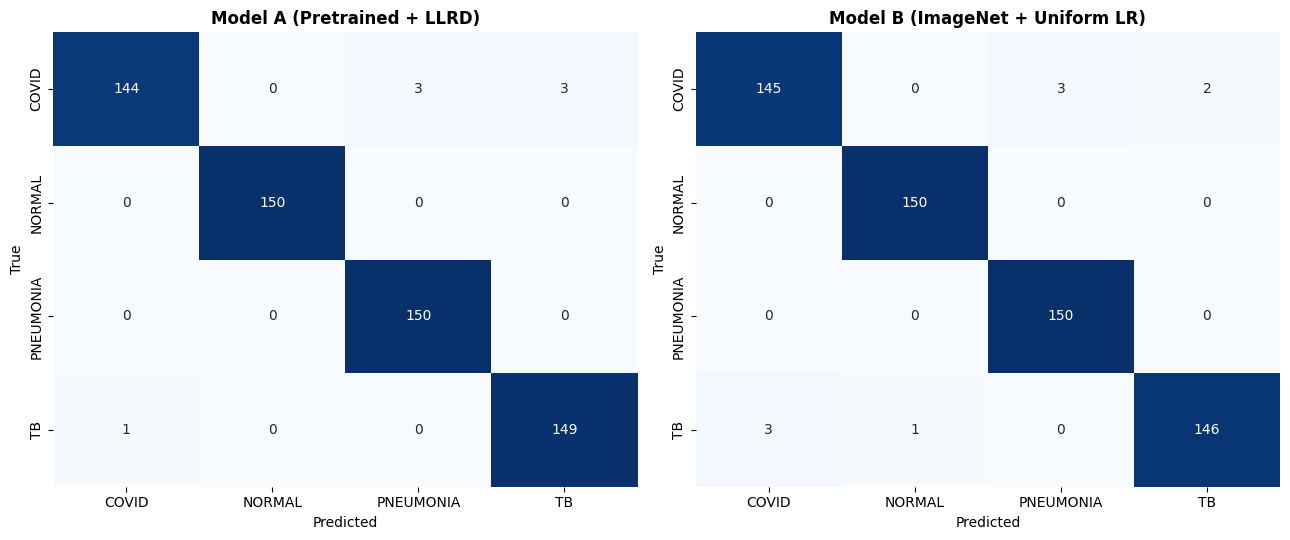


 SUMMARY: Model A test acc = 0.9883 | Model B test acc = 0.9850


In [13]:
# =====================================================================
# CELL 11: HELD-OUT TEST SET — ENSEMBLE EVALUATION (MODEL A vs MODEL B)
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

kano_test_dataset = KanoCXRDataset(KANO_TEST_DIR, transform=eval_transforms, apply_clahe=True)
test_loader = DataLoader(kano_test_dataset, batch_size=32, shuffle=False, num_workers=4)

test_labels_true = np.array([lbl for _, lbl in kano_test_dataset.image_data])

def ensemble_predict(checkpoint_paths, test_loader):
    """Soft-vote ensemble: average softmax probabilities across all 5 fold models."""
    all_probs = None
    for ckpt_path in checkpoint_paths:
        model = densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model = model.to(DEVICE).eval()

        fold_probs = []
        with torch.no_grad():
            for images, _ in test_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                fold_probs.append(probs)
        fold_probs = np.concatenate(fold_probs, axis=0)

        all_probs = fold_probs if all_probs is None else all_probs + fold_probs

    avg_probs = all_probs / len(checkpoint_paths)
    preds = np.argmax(avg_probs, axis=1)
    return preds, avg_probs

# --- Model A ensemble ---
model_a_checkpoints = [f"modelA_fold{i}.pth" for i in range(1, 6)]
preds_a, probs_a = ensemble_predict(model_a_checkpoints, test_loader)

print("=" * 70)
print("MODEL A — HELD-OUT TEST SET (5-FOLD ENSEMBLE)")
print("=" * 70)
print(classification_report(test_labels_true, preds_a, target_names=CLASS_NAMES, digits=4))
acc_a_test = (preds_a == test_labels_true).mean()
print(f"Overall Test Accuracy: {acc_a_test:.4f}")

# --- Model B ensemble ---
model_b_checkpoints = [f"modelB_fold{i}.pth" for i in range(1, 6)]
preds_b, probs_b = ensemble_predict(model_b_checkpoints, test_loader)

print("\n" + "=" * 70)
print("MODEL B — HELD-OUT TEST SET (5-FOLD ENSEMBLE)")
print("=" * 70)
print(classification_report(test_labels_true, preds_b, target_names=CLASS_NAMES, digits=4))
acc_b_test = (preds_b == test_labels_true).mean()
print(f"Overall Test Accuracy: {acc_b_test:.4f}")

# --- Confusion matrices, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, preds, title in [(axes[0], preds_a, "Model A (Pretrained + LLRD)"),
                          (axes[1], preds_b, "Model B (ImageNet + Uniform LR)")]:
    cm = confusion_matrix(test_labels_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

print(f"\n SUMMARY: Model A test acc = {acc_a_test:.4f} | Model B test acc = {acc_b_test:.4f}")

## Statistical significance + mimic-confusion breakdown (this is the analysis that actually answers our research question)

In [14]:
# =====================================================================
# CELL 12: SIGNIFICANCE TESTING + MIMIC-CONFUSION BREAKDOWN
# =====================================================================
from statsmodels.stats.contingency_tables import mcnemar

# --- 1. McNemar's test on OVERALL correctness (paired, same 600 test images) ---
correct_a = (preds_a == test_labels_true)
correct_b = (preds_b == test_labels_true)

# 2x2 contingency table: [[both correct, A correct/B wrong], [A wrong/B correct, both wrong]]
both_correct = np.sum(correct_a & correct_b)
a_only = np.sum(correct_a & ~correct_b)
b_only = np.sum(~correct_a & correct_b)
both_wrong = np.sum(~correct_a & ~correct_b)

contingency = [[both_correct, a_only], [b_only, both_wrong]]
result = mcnemar(contingency, exact=True)

print("=" * 70)
print("MCNEMAR'S TEST — OVERALL TEST-SET ACCURACY (Model A vs Model B)")
print("=" * 70)
print(f"  Both correct: {both_correct} | A-only correct: {a_only} | B-only correct: {b_only} | Both wrong: {both_wrong}")
print(f"  McNemar statistic: {result.statistic:.4f}, p-value: {result.pvalue:.4f}")
print(f"  {'✅ Statistically significant (p<0.05)' if result.pvalue < 0.05 else '⚠️ NOT statistically significant at p<0.05 — overall accuracy gap may be noise'}")

# --- 2. Bootstrap 95% CI on overall accuracy for each model ---
def bootstrap_accuracy_ci(preds, labels, n_boot=2000, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(labels)
    accs = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        accs.append((preds[idx] == labels[idx]).mean())
    return np.percentile(accs, 2.5), np.percentile(accs, 97.5)

ci_a = bootstrap_accuracy_ci(preds_a, test_labels_true)
ci_b = bootstrap_accuracy_ci(preds_b, test_labels_true)
print(f"\n  Model A accuracy: {acc_a_test:.4f}  [95% CI: {ci_a[0]:.4f}–{ci_a[1]:.4f}]")
print(f"  Model B accuracy: {acc_b_test:.4f}  [95% CI: {ci_b[0]:.4f}–{ci_b[1]:.4f}]")

# --- 3. TB-specific McNemar test (does pretraining specifically help TB recall?) ---
tb_mask = (test_labels_true == CLASS_NAMES.index("TB"))
tb_correct_a = correct_a[tb_mask]
tb_correct_b = correct_b[tb_mask]

tb_both_correct = np.sum(tb_correct_a & tb_correct_b)
tb_a_only = np.sum(tb_correct_a & ~tb_correct_b)
tb_b_only = np.sum(~tb_correct_a & tb_correct_b)
tb_both_wrong = np.sum(~tb_correct_a & ~tb_correct_b)

tb_contingency = [[tb_both_correct, tb_a_only], [tb_b_only, tb_both_wrong]]
tb_result = mcnemar(tb_contingency, exact=True)

print("\n" + "=" * 70)
print("MCNEMAR'S TEST — TB RECALL SPECIFICALLY (Model A vs Model B)")
print("=" * 70)
print(f"  TB recall — Model A: {tb_correct_a.mean():.4f} | Model B: {tb_correct_b.mean():.4f}")
print(f"  Both correct: {tb_both_correct} | A-only: {tb_a_only} | B-only: {tb_b_only} | Both wrong: {tb_both_wrong}")
print(f"  McNemar statistic: {tb_result.statistic:.4f}, p-value: {tb_result.pvalue:.4f}")
print(f"  {'✅ Statistically significant (p<0.05)' if tb_result.pvalue < 0.05 else '⚠️ NOT statistically significant — TB recall gap may be noise given n=150'}")

# --- 4. Mimic-confusion breakdown: where do TB errors actually go? ---
print("\n" + "=" * 70)
print("TB MISCLASSIFICATION BREAKDOWN (Objective 5)")
print("=" * 70)
tb_true_idx = CLASS_NAMES.index("TB")
for model_name, preds in [("Model A", preds_a), ("Model B", preds_b)]:
    tb_preds = preds[tb_mask]
    n_tb = len(tb_preds)
    print(f"\n  {model_name} — TB test cases (n={n_tb}):")
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        count = np.sum(tb_preds == cls_idx)
        pct = 100 * count / n_tb
        marker = "  <- correct" if cls_idx == tb_true_idx else ""
        print(f"    Predicted {cls_name:10s}: {count:3d} ({pct:5.2f}%){marker}")

# --- 5. Abnormal-vs-Normal decomposition (Objective 6) ---
print("\n" + "=" * 70)
print("ABNORMAL-VS-NORMAL vs MIMIC-DIFFERENTIAL DECOMPOSITION (Objective 6)")
print("=" * 70)
normal_idx = CLASS_NAMES.index("NORMAL")

for model_name, preds in [("Model A", preds_a), ("Model B", preds_b)]:
    # Binary: is it correctly identified as abnormal vs normal?
    true_abnormal = (test_labels_true != normal_idx)
    pred_abnormal = (preds != normal_idx)
    abnormal_vs_normal_acc = (true_abnormal == pred_abnormal).mean()

    # Mimic-only: restrict to true abnormal cases, check 3-way differential among COVID/PNEUMONIA/TB
    mimic_mask = true_abnormal
    mimic_correct = (preds[mimic_mask] == test_labels_true[mimic_mask]).mean()

    print(f"  {model_name}: Abnormal-vs-Normal acc = {abnormal_vs_normal_acc:.4f} | "
          f"Mimic-differential acc (COVID/PNEUMONIA/TB only) = {mimic_correct:.4f}")

MCNEMAR'S TEST — OVERALL TEST-SET ACCURACY (Model A vs Model B)
  Both correct: 590 | A-only correct: 3 | B-only correct: 1 | Both wrong: 6
  McNemar statistic: 1.0000, p-value: 0.6250
  ⚠️ NOT statistically significant at p<0.05 — overall accuracy gap may be noise

  Model A accuracy: 0.9883  [95% CI: 0.9783–0.9950]
  Model B accuracy: 0.9850  [95% CI: 0.9750–0.9933]

MCNEMAR'S TEST — TB RECALL SPECIFICALLY (Model A vs Model B)
  TB recall — Model A: 0.9933 | Model B: 0.9733
  Both correct: 146 | A-only: 3 | B-only: 0 | Both wrong: 1
  McNemar statistic: 0.0000, p-value: 0.2500
  ⚠️ NOT statistically significant — TB recall gap may be noise given n=150

TB MISCLASSIFICATION BREAKDOWN (Objective 5)

  Model A — TB test cases (n=150):
    Predicted COVID     :   1 ( 0.67%)
    Predicted NORMAL    :   0 ( 0.00%)
    Predicted PNEUMONIA :   0 ( 0.00%)
    Predicted TB        : 149 (99.33%)  <- correct

  Model B — TB test cases (n=150):
    Predicted COVID     :   3 ( 2.00%)
    Predicted

## Paired bootstrap on the accuracy difference (Model A − Model B)

PAIRED BOOTSTRAP: MODEL A vs MODEL B

  Overall Test Accuracy (n=600)
    Mean difference (A - B): +0.0034
    95% CI on difference:    [-0.0033, +0.0100]
    A better in 77.8% of resamples | tied in 13.0% | B better in 9.2%
    ⚠️ CI includes zero — cannot rule out no difference

  TB Recall (n=150)
    Mean difference (A - B): +0.0199
    95% CI on difference:    [+0.0000, +0.0467]
    A better in 94.9% of resamples | tied in 5.1% | B better in 0.0%
    ⚠️ CI includes zero — cannot rule out no difference

  Mimic-Differential Accuracy (COVID/PNEUMONIA/TB only, n=450)
    Mean difference (A - B): +0.0044
    95% CI on difference:    [-0.0044, +0.0133]
    A better in 77.3% of resamples | tied in 13.6% | B better in 9.2%
    ⚠️ CI includes zero — cannot rule out no difference


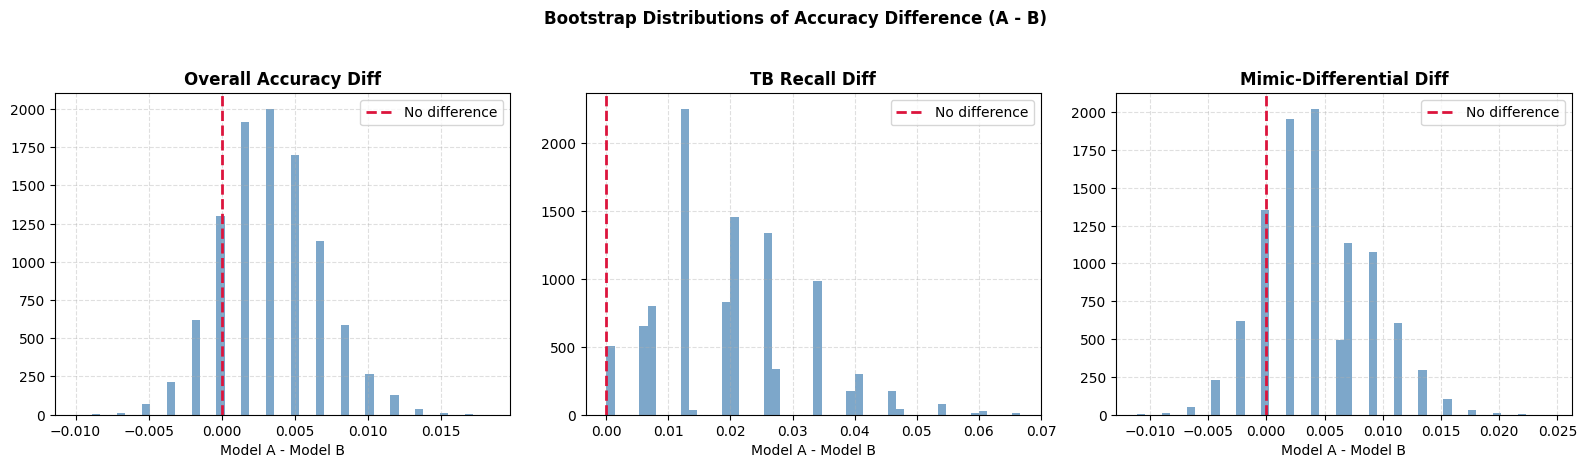

In [15]:
# =====================================================================
# CELL 13: PAIRED BOOTSTRAP ON THE ACCURACY DIFFERENCE (A - B)
# =====================================================================
# McNemar's test asks "is there a difference?" against a strict null and
# has low power when discordant pairs are rare (as we just saw). This
# paired bootstrap instead directly estimates the DIFFERENCE in accuracy
# (resampling test images, not treating each model separately), which is
# more informative when performance is near ceiling and errors are sparse.
# =====================================================================
def paired_bootstrap_diff(preds_a, preds_b, labels, n_boot=10000, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(labels)
    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        acc_a = (preds_a[idx] == labels[idx]).mean()
        acc_b = (preds_b[idx] == labels[idx]).mean()
        diffs.append(acc_a - acc_b)
    diffs = np.array(diffs)
    return diffs

def summarize_bootstrap(diffs, label):
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    pct_a_better = 100 * np.mean(diffs > 0)
    pct_tied = 100 * np.mean(diffs == 0)
    pct_b_better = 100 * np.mean(diffs < 0)
    print(f"\n  {label}")
    print(f"    Mean difference (A - B): {diffs.mean():+.4f}")
    print(f"    95% CI on difference:    [{ci_low:+.4f}, {ci_high:+.4f}]")
    print(f"    A better in {pct_a_better:.1f}% of resamples | "
          f"tied in {pct_tied:.1f}% | B better in {pct_b_better:.1f}%")
    if ci_low > 0:
        print(f"    ✅ CI excludes zero — A is reliably better on this metric")
    elif ci_high < 0:
        print(f"    ✅ CI excludes zero — B is reliably better on this metric")
    else:
        print(f"    ⚠️ CI includes zero — cannot rule out no difference")

print("=" * 70)
print("PAIRED BOOTSTRAP: MODEL A vs MODEL B")
print("=" * 70)

# Overall accuracy difference
overall_diffs = paired_bootstrap_diff(preds_a, preds_b, test_labels_true)
summarize_bootstrap(overall_diffs, "Overall Test Accuracy (n=600)")

# TB recall difference specifically (restrict to TB rows)
tb_true_only = test_labels_true[tb_mask]
tb_preds_a_only = preds_a[tb_mask]
tb_preds_b_only = preds_b[tb_mask]
tb_diffs = paired_bootstrap_diff(tb_preds_a_only, tb_preds_b_only, tb_true_only)
summarize_bootstrap(tb_diffs, "TB Recall (n=150)")

# Mimic-differential accuracy difference (COVID/PNEUMONIA/TB only, excluding Normal)
mimic_mask_bool = (test_labels_true != normal_idx)
mimic_true_only = test_labels_true[mimic_mask_bool]
mimic_preds_a_only = preds_a[mimic_mask_bool]
mimic_preds_b_only = preds_b[mimic_mask_bool]
mimic_diffs = paired_bootstrap_diff(mimic_preds_a_only, mimic_preds_b_only, mimic_true_only)
summarize_bootstrap(mimic_diffs, "Mimic-Differential Accuracy (COVID/PNEUMONIA/TB only, n=450)")

# --- Visualize the bootstrap distributions ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, diffs, title in zip(axes,
                             [overall_diffs, tb_diffs, mimic_diffs],
                             ["Overall Accuracy Diff", "TB Recall Diff", "Mimic-Differential Diff"]):
    ax.hist(diffs, bins=50, color="steelblue", alpha=0.7)
    ax.axvline(0, color="crimson", linestyle="--", linewidth=2, label="No difference")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Model A - Model B")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)
plt.suptitle("Bootstrap Distributions of Accuracy Difference (A - B)", fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Quantitative Grad-CAM lung-attention comparison

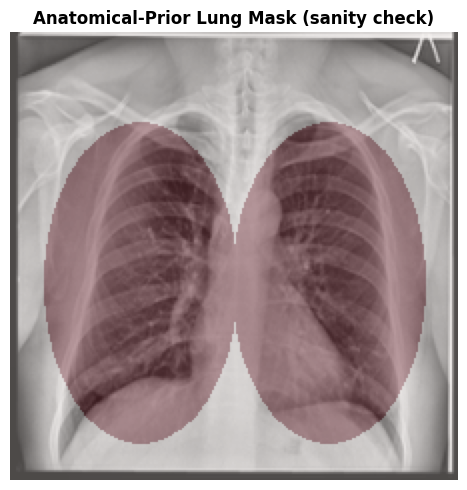

👀 Confirm the red regions roughly cover both lung fields before proceeding.


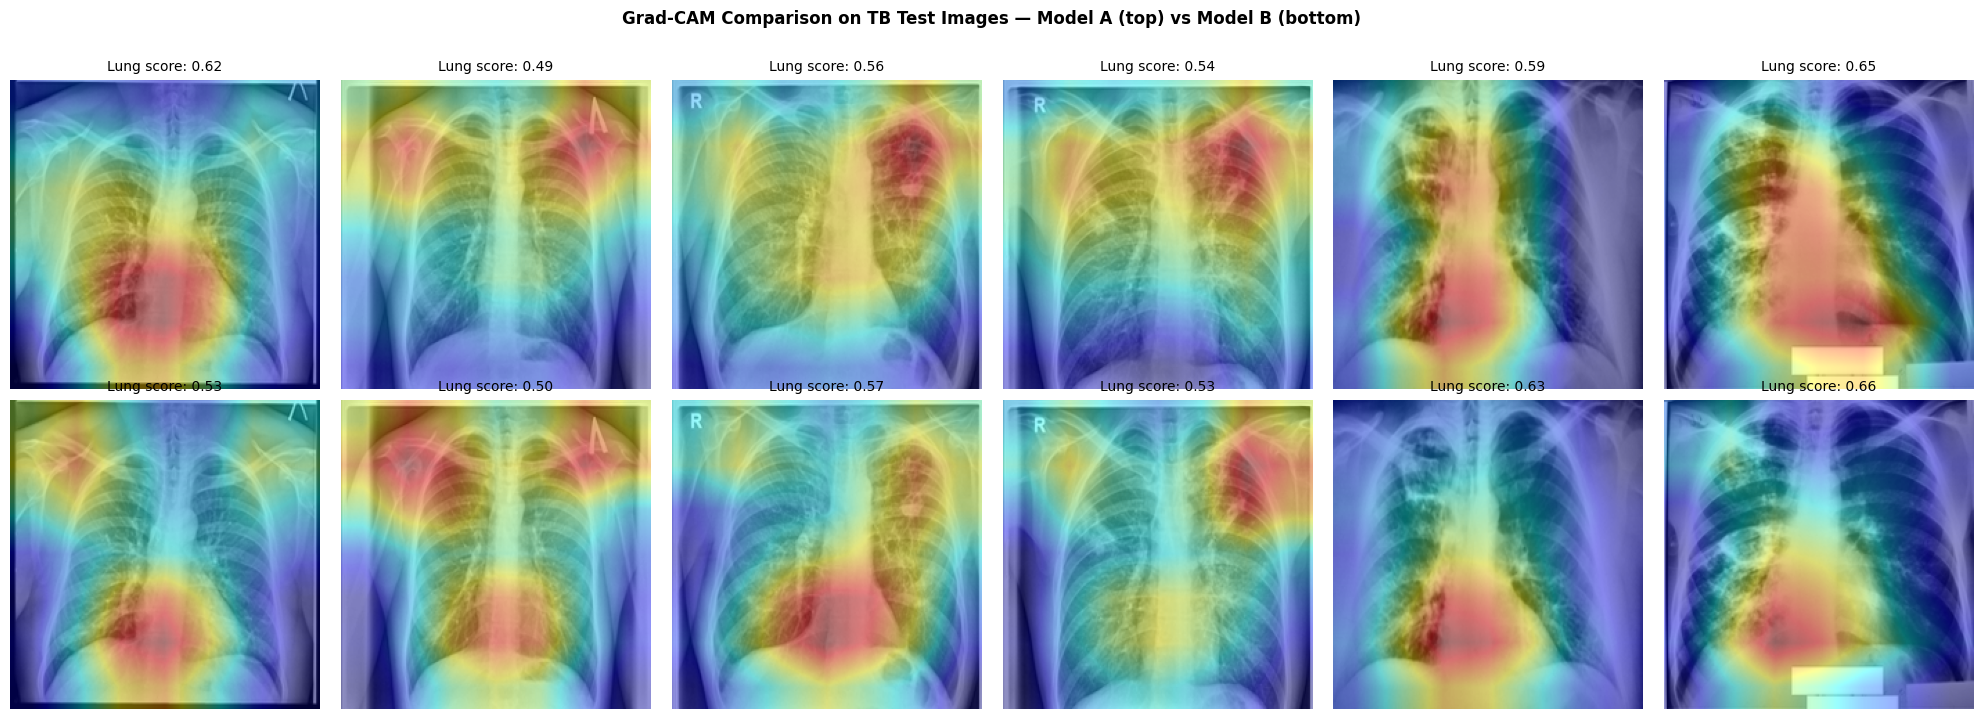

LUNG-ATTENTION SCORE SUMMARY (TB test images, n=20)
  Model A: mean=0.5850, std=0.0653
  Model B: mean=0.6068, std=0.0467

  Paired t-test (same 20 images): t=-1.3954, p=0.1790
  ⚠️ Not statistically significant


/tmp/ipykernel_58/1269055138.py:154: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_a, scores_b], labels=["Model A", "Model B"])


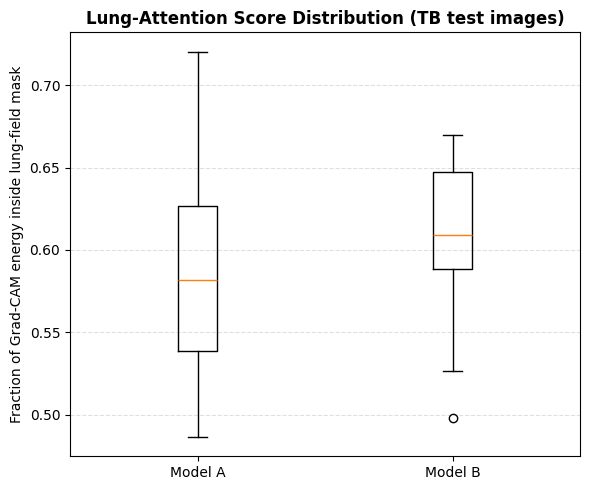

In [16]:
# =====================================================================
# CELL 14: QUANTITATIVE GRAD-CAM — LUNG-ATTENTION SCORE (Objective 7)
# =====================================================================
# Approach: rather than a full lung segmentation model (extra dependency,
# extra download), we use a fixed anatomical-prior mask — two ellipses
# approximating left/right lung fields on the 224x224 preprocessed image.
# This is a coarse approximation, not pixel-perfect segmentation, but it's
# transparent, reproducible, and sufficient for a RELATIVE comparison
# between Model A and Model B on the same images (which is what we need).
# Grad-CAM is run on Fold 1 of each model as a representative instance
# (not the full ensemble, which isn't practical to backprop through).
# =====================================================================
import cv2

# --- Build the anatomical-prior lung mask (224x224) ---
def build_lung_mask(img_size=224):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    # Left lung field (image-left)
    cv2.ellipse(mask, center=(65, 125), axes=(48, 80), angle=0,
                startAngle=0, endAngle=360, color=1.0, thickness=-1)
    # Right lung field (image-right)
    cv2.ellipse(mask, center=(159, 125), axes=(48, 80), angle=0,
                startAngle=0, endAngle=360, color=1.0, thickness=-1)
    return mask

lung_mask = build_lung_mask()

# --- Visual sanity check: overlay the mask on a sample TB image ---
sample_tb_path = sorted(glob.glob(os.path.join(KANO_TEST_DIR, "TB", "*.png")))[0]
sample_img = load_and_preprocess(sample_tb_path, apply_clahe=True)
sample_arr = np.array(sample_img)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(sample_arr, cmap="gray")
ax.imshow(lung_mask, cmap="Reds", alpha=0.3)
ax.set_title("Anatomical-Prior Lung Mask (sanity check)", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()
print("👀 Confirm the red regions roughly cover both lung fields before proceeding.")

# --- Grad-CAM engine for the 4-class models ---
class GradCAM4Class:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, module, input, output):
        self.activations = output.clone()

    def generate_heatmap(self, input_tensor, class_idx):
        self.model.zero_grad()
        _ = self.model(input_tensor)
        feature_maps = self.activations.detach().clone().requires_grad_(True)
        x = torch.relu(feature_maps)
        x = torch.nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        output = self.model.classifier(x)
        score = output[0][class_idx]
        grads = torch.autograd.grad(score, feature_maps)[0]
        weights = torch.mean(grads, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * feature_maps, dim=1).squeeze()
        cam = torch.clamp(cam, min=0).detach().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def lung_attention_score(heatmap, mask):
    """Fraction of total heatmap 'energy' falling inside the lung-field mask."""
    total_energy = heatmap.sum()
    if total_energy == 0:
        return 0.0
    in_mask_energy = (heatmap * mask).sum()
    return in_mask_energy / total_energy

# --- Load Fold-1 representative checkpoint for each model ---
def load_model_for_gradcam(checkpoint_path):
    model = densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model.to(DEVICE).eval()

model_a_gc = load_model_for_gradcam("modelA_fold1.pth")
model_b_gc = load_model_for_gradcam("modelB_fold1.pth")

cam_a = GradCAM4Class(model_a_gc, model_a_gc.features.norm5)
cam_b = GradCAM4Class(model_b_gc, model_b_gc.features.norm5)

# --- Run on a sample of TB test images (the class most central to the paper) ---
tb_test_files = sorted(glob.glob(os.path.join(KANO_TEST_DIR, "TB", "*.png")))[:20]

scores_a, scores_b = [], []
sample_overlays = []  # keep a few for the qualitative grid

for i, img_path in enumerate(tb_test_files):
    pil_img = load_and_preprocess(img_path, apply_clahe=True)
    img_arr = np.array(pil_img)
    input_tensor = eval_transforms(pil_img).unsqueeze(0).to(DEVICE)

    tb_idx = CLASS_NAMES.index("TB")
    heatmap_a = cam_a.generate_heatmap(input_tensor, tb_idx)
    heatmap_b = cam_b.generate_heatmap(input_tensor, tb_idx)

    score_a = lung_attention_score(heatmap_a, lung_mask)
    score_b = lung_attention_score(heatmap_b, lung_mask)
    scores_a.append(score_a)
    scores_b.append(score_b)

    if i < 6:  # keep first 6 for the visual grid
        heat_a_color = cv2.applyColorMap(np.uint8(255 * heatmap_a), cv2.COLORMAP_JET)
        heat_a_color = cv2.cvtColor(heat_a_color, cv2.COLOR_BGR2RGB)
        overlay_a = cv2.addWeighted(img_arr, 0.6, heat_a_color, 0.4, 0)

        heat_b_color = cv2.applyColorMap(np.uint8(255 * heatmap_b), cv2.COLORMAP_JET)
        heat_b_color = cv2.cvtColor(heat_b_color, cv2.COLOR_BGR2RGB)
        overlay_b = cv2.addWeighted(img_arr, 0.6, heat_b_color, 0.4, 0)

        sample_overlays.append((overlay_a, overlay_b, score_a, score_b))

scores_a = np.array(scores_a)
scores_b = np.array(scores_b)

# --- Qualitative grid: Model A vs Model B, 6 TB images ---
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for col, (ov_a, ov_b, sa, sb) in enumerate(sample_overlays):
    axes[0, col].imshow(ov_a)
    axes[0, col].set_title(f"Lung score: {sa:.2f}", fontsize=10)
    axes[0, col].axis("off")
    axes[1, col].imshow(ov_b)
    axes[1, col].set_title(f"Lung score: {sb:.2f}", fontsize=10)
    axes[1, col].axis("off")
axes[0, 0].set_ylabel("Model A", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Model B", fontsize=13, fontweight="bold")
plt.suptitle("Grad-CAM Comparison on TB Test Images — Model A (top) vs Model B (bottom)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Quantitative summary ---
print("=" * 70)
print("LUNG-ATTENTION SCORE SUMMARY (TB test images, n=20)")
print("=" * 70)
print(f"  Model A: mean={scores_a.mean():.4f}, std={scores_a.std():.4f}")
print(f"  Model B: mean={scores_b.mean():.4f}, std={scores_b.std():.4f}")

from scipy import stats as sstats
t_stat, p_val = sstats.ttest_rel(scores_a, scores_b)  # paired, same images
print(f"\n  Paired t-test (same 20 images): t={t_stat:.4f}, p={p_val:.4f}")
print(f"  {'✅ Statistically significant' if p_val < 0.05 else '⚠️ Not statistically significant'}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([scores_a, scores_b], labels=["Model A", "Model B"])
ax.set_title("Lung-Attention Score Distribution (TB test images)", fontweight="bold")
ax.set_ylabel("Fraction of Grad-CAM energy inside lung-field mask")
ax.grid(True, axis='y', linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()